In [1]:
import glob
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import shutil

In [2]:
def read_data_path(path):
    files = glob.glob(f'{path}/**/*.jpg', recursive=True)
    return files

In [3]:
files = read_data_path(path="C:/Non-work/ML/Nepali-liscence-number-recognition/Dataset/images")

In [4]:
# Initialize a dictionary to store the number of files in each class
def make_data_csv(image_path_list):
    class_counts = {}
    labels = []

    for file_path in image_path_list:
        class_name = os.path.basename(os.path.dirname(file_path))
        labels.append(class_name)
    data_dict = {"Images": image_path_list, "Labels": labels}
    dataset = pd.DataFrame(data_dict)
        
    return dataset


In [5]:
dataset_df = make_data_csv(image_path_list=files)

In [6]:
dataset_df

,Images,Labels
0,C:/Non-work/ML/Nepali-liscence-number-recognit...,0
1,C:/Non-work/ML/Nepali-liscence-number-recognit...,0
2,C:/Non-work/ML/Nepali-liscence-number-recognit...,0
3,C:/Non-work/ML/Nepali-liscence-number-recognit...,0
4,C:/Non-work/ML/Nepali-liscence-number-recognit...,0
...,...,...
2028,C:/Non-work/ML/Nepali-liscence-number-recognit...,pa
2029,C:/Non-work/ML/Nepali-liscence-number-recognit...,pa
2030,C:/Non-work/ML/Nepali-liscence-number-recognit...,pa
2031,C:/Non-work/ML/Nepali-liscence-number-recognit...,pa


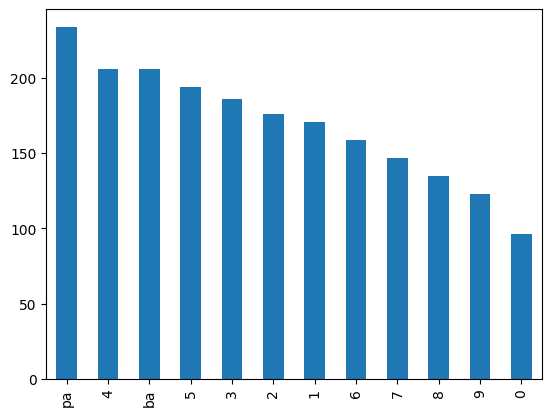

In [7]:
classes = dataset_df.Labels.value_counts().plot(kind='bar')

In [8]:
def read_images(image_path, size=()):
    image = Image.open(image_path)
    if len(size)>0:
        image = image.resize(size)
    return image    

In [9]:
image_sample = read_images("C:/Non-work/ML/Nepali-liscence-number-recognition/Dataset/images\\4\\149.jpg")

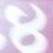

In [10]:
image_sample

In [11]:
# image_array = np.asarray(image_sample)

In [12]:
# image_array.shape

In [11]:
import torch
import torchvision.transforms as T

In [12]:
def change_color(image_path, brightness=.5, hue=.3):
    image = read_images(image_path)
    jitter = T.ColorJitter(brightness=brightness, hue=hue)
    jitted_imgs = jitter(image)
    return jitted_imgs

In [13]:
classes = dict(dataset_df.Labels.value_counts())
highest_label_count = max(classes.values())
highest_label_count

234

In [16]:
def augument_dataset():
    augumented_path = "C:/Non-work/ML/Nepali-liscence-number-recognition/Dataset/augumented"
    if not os.path.exists(augumented_path):
        os.makedirs(augumented_path)
    for key, value in classes.items():
        matched_label = dataset_df.loc[dataset_df["Labels"] == key]
        present_label_count = len(matched_label)
        for index, row in matched_label.iterrows():
            src_path = row["Images"]
    #         print(src_path)
            filename = os.path.basename(src_path)
            class_name = key
            dst_path = augumented_path+ "/" + class_name + "/" + filename
            if not os.path.exists(augumented_path+ "/" + class_name):
                os.makedirs(augumented_path+ "/" + class_name)
            shutil.copy(src_path, dst_path)

            brightness_factor = [.3,.4,.5]
            for i, brightness in enumerate(brightness_factor):
                if present_label_count< highest_label_count:
    #                 print("src file   ", src_path)
                    change_image = change_color(image_path=src_path, brightness=brightness)
                    new_path = augumented_path +"/"+str(class_name) + "/" + str(i) + filename 
    #                 print("new path   ", new_path)
                    change_image.save(new_path)
    #                 change_image.save(f"{augumented_path}/{class_name}/{i}{filename}")
                    present_label_count +=1
    #                 print(present_label_count)


In [17]:
# X=dataset_df["Images"]
# y=dataset_df["Labels"]
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=42, stratify=y)

In [18]:
# data_dict = {"Images":X_test, "Labels":y_test}
# test_data = pd.DataFrame(data_dict)

In [20]:
# augument_dataset()

In [14]:
augumented_path = "C:/Non-work/ML/Nepali-liscence-number-recognition/Dataset/augumented"
augumented_files = read_data_path(path=augumented_path)
aug_dataset_df = make_data_csv(image_path_list=augumented_files)

In [15]:
aug_dataset_df.Labels.value_counts()

pa    234
4     231
ba    231
1     230
2     230
3     230
5     230
6     229
7     229
8     229
0     224
9     219
Name: Labels, dtype: int64

In [21]:
def make_greyscale(image_path):
    gray_img = T.Grayscale()(image_path)
    return gray_img

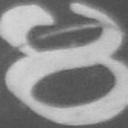

In [22]:
sample_img = read_images("C:/Non-work/ML/Nepali-liscence-number-recognition/Dataset/augumented\\4\\101.jpg", size = (128,128))
sample_gray = make_greyscale(sample_img)
sample_gray

In [23]:
X = aug_dataset_df["Images"]
y = aug_dataset_df["Labels"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [24]:
train_df = pd.DataFrame({"Images": X_train, "Labels":y_train})
test_df = pd.DataFrame({"Images": X_test, "Labels":y_test})

In [25]:
train_df.Labels.value_counts()

pa    187
4     185
ba    185
5     184
2     184
3     184
1     184
6     183
7     183
8     183
0     179
9     175
Name: Labels, dtype: int64

In [ ]:
len(test_df)

In [35]:
tensor_data = T.ToTensor()

In [42]:
img_tensor = tensor_data(sample_img)

In [45]:
img_tensor

tensor([[[0.7412, 0.7373, 0.7333,  ..., 0.6627, 0.6627, 0.6549],
         [0.7176, 0.7216, 0.7294,  ..., 0.6706, 0.6706, 0.6667],
         [0.7137, 0.7176, 0.7255,  ..., 0.6745, 0.6706, 0.6706],
         ...,
         [0.7059, 0.7098, 0.7098,  ..., 0.6745, 0.6706, 0.6745],
         [0.7059, 0.7098, 0.7059,  ..., 0.6706, 0.6667, 0.6706],
         [0.7098, 0.7098, 0.7059,  ..., 0.6706, 0.6706, 0.6706]],

        [[0.2039, 0.2000, 0.1961,  ..., 0.1529, 0.1451, 0.1373],
         [0.1882, 0.1922, 0.2000,  ..., 0.1608, 0.1529, 0.1490],
         [0.1961, 0.2039, 0.2118,  ..., 0.1608, 0.1529, 0.1529],
         ...,
         [0.1490, 0.1529, 0.1608,  ..., 0.1843, 0.1882, 0.1882],
         [0.1490, 0.1529, 0.1569,  ..., 0.1765, 0.1804, 0.1765],
         [0.1529, 0.1529, 0.1569,  ..., 0.1725, 0.1725, 0.1725]],

        [[0.2745, 0.2706, 0.2667,  ..., 0.1922, 0.1882, 0.1804],
         [0.2549, 0.2588, 0.2667,  ..., 0.2000, 0.1961, 0.1922],
         [0.2627, 0.2667, 0.2745,  ..., 0.2000, 0.1961, 0.

In [16]:
from torch.utils.data import Dataset, DataLoader

In [46]:
transform = T.Compose([
    T.Resize((28, 28)),  # Resize image to 28x28
    T.Grayscale(),  # Convert image to grayscale
    T.ToTensor(),  # Convert image to tensor
    T.Normalize((0.5,), (0.5,))  # Normalize image
])

In [50]:
class HandWrittenImageDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.dataset = csv_file
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img_path = self.dataset.iloc[idx]["Images"]
        label = self.dataset.iloc[idx]["Labels"]
        img = Image.open(img_path)

        if self.transform:
            img = self.transform(img)

        return img, label


In [51]:
# Define the path to your CSV file and image folder
# csv_file_path = "path/to/your/csv/file.csv"
# img_folder_path = "path/to/your/image/folder/"

# Define the transforms to be applied to each image

# Create a custom dataset using the CSV file
dataset = HandWrittenImageDataset(train_df, transform=transform)



In [31]:
dataset.__len__

<bound method CustomDataset.__len__ of <__main__.CustomDataset object at 0x000001E7934D6B00>>

In [52]:
# Create a dataloader using the custom dataset
train_dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

Feature batch shape: torch.Size([32, 1, 28, 28])


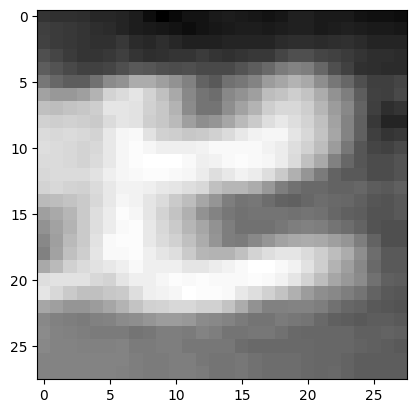

Label: 9


In [59]:
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
# print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

In [56]:
train_labels

('7',
 '1',
 'pa',
 '5',
 '8',
 '8',
 '5',
 '4',
 '9',
 'pa',
 '9',
 '9',
 '1',
 '4',
 '7',
 '9',
 '6',
 'pa',
 '7',
 '0',
 '5',
 'pa',
 '9',
 '4',
 '5',
 'pa',
 '3',
 '3',
 '9',
 '1',
 '1',
 '2')

In [ ]:
to_img = T.ToPILImage()
